## Load data

In [1]:
# Load data
import pandas as pd

df_fasttext_aligned = pd.read_pickle('../data/words10_embeddings_fasttext_aligned.pkl')
df_fasttext = pd.read_pickle('../data/words10_embeddings_fasttext.pkl')
df_para = pd.read_pickle('../data/words10_embeddings_paraphrase-multilingual-MiniLM-L12-v2.pkl')
df_labse = pd.read_pickle('../data/words10_embeddings_LaBSE.pkl')

In [2]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

def calculate_avg_neighbor_cosine(row):
    word_cols = row.index[2:]  # Assuming first two cols are language & model
    embeddings = [row[col] for col in word_cols if isinstance(row[col], np.ndarray)]
    
    # Compute cosine similarity between consecutive embeddings only
    neighbor_sims = [
        cosine_similarity(embeddings[i].reshape(1, -1), embeddings[i+1].reshape(1, -1))[0, 0]
        for i in range(len(embeddings) - 1)
    ]
    
    avg_neighbor_cosine = np.mean(neighbor_sims)

    # compute avg similairity
    similarities = cosine_similarity(embeddings)
    upper_triangle = similarities[np.triu_indices_from(similarities, k=1)]
    
    avg_cosine = np.mean(upper_triangle)
    
    return pd.Series({
        "avg_neighbor_cosine": avg_neighbor_cosine,
        "avg_cosine": avg_cosine
    })

def process_model_long(df_embeddings, model_name):
    sims_df = df_embeddings.apply(calculate_avg_neighbor_cosine, axis=1)
    
    sims_df["language"] = df_embeddings["language"]
    sims_df["model"] = df_embeddings["model"]
    sims_df["embedding_model"] = model_name
    
    return sims_df

# Combine results from all models
final_df = pd.concat([
    process_model_long(df_fasttext_aligned, "fastText (aligned)"),
    process_model_long(df_fasttext, "fastText"),
    process_model_long(df_labse, "LaBSE"),
    process_model_long(df_para, "paraphrase-multilingual-MiniLM-L12-v2"),
])

In [3]:
final_df.tail()

,avg_neighbor_cosine,avg_cosine,language,model,embedding_model
139,0.521037,0.503652,french,human,paraphrase-multilingual-MiniLM-L12-v2
140,0.397077,0.410418,french,human,paraphrase-multilingual-MiniLM-L12-v2
141,0.437405,0.412692,french,human,paraphrase-multilingual-MiniLM-L12-v2
142,0.488346,0.493166,french,human,paraphrase-multilingual-MiniLM-L12-v2
143,0.470110,0.475713,french,human,paraphrase-multilingual-MiniLM-L12-v2


In [4]:
final_df.to_csv('../data/cosine_similairity_neigbor.csv')

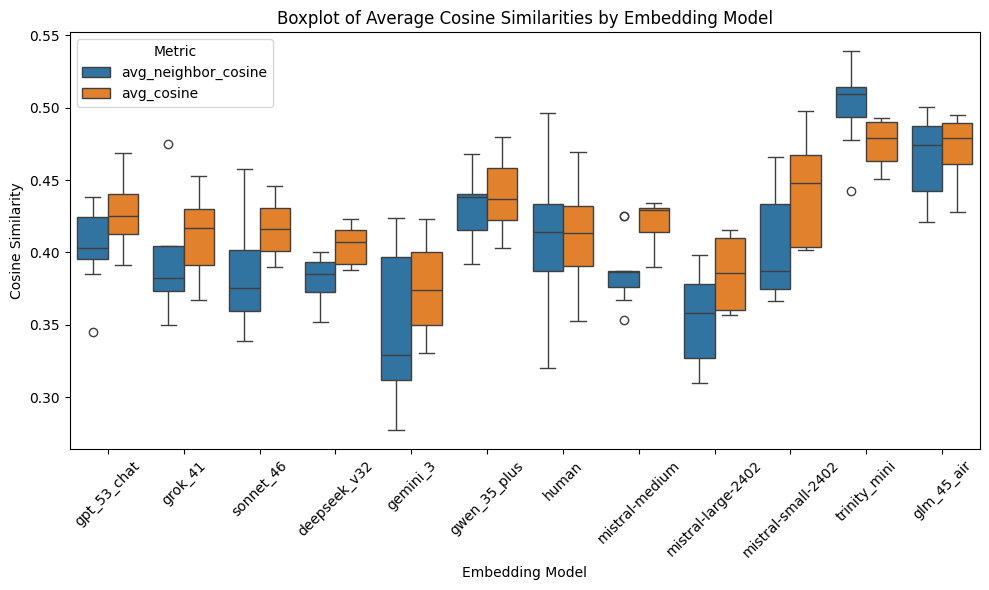

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt


df_filtered = final_df[final_df['embedding_model'] == 'LaBSE']

# Melt the DataFrame so both metrics can be plotted together
plot_df = df_filtered.melt(
    id_vars=["model"], 
    value_vars=["avg_neighbor_cosine", "avg_cosine"],
    var_name="metric", 
    value_name="similarity"
)

plt.figure(figsize=(10, 6))
sns.boxplot(x="model", y="similarity", hue="metric", data=plot_df)
plt.xticks(rotation=45)
plt.title("Boxplot of Average Cosine Similarities by Embedding Model")
plt.ylabel("Cosine Similarity")
plt.xlabel("Embedding Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()